# Rank Prediction — Learning to Rank (LTR)

## Why pivot away from regression/classification
Predicting the exact `matched_score` treats every job posting as equally hard to
score, and getting an absolute number right (or a threshold-based accept/reject)
isn't actually what a screening tool needs. What matters is: **for this specific
job, which candidates should be looked at first?** That's a ranking problem, not
a regression problem — the model only needs to get the *relative order* of
candidates right within a `job_position_name`, not their exact decimal score.

`XGBRanker` and `LGBMRanker` optimize for this directly: instead of minimizing
squared error against a single number, they're trained on **groups** (one group
per job posting) and penalized for putting a worse candidate above a better one
*within that group*. A candidate is never compared across different jobs.

This notebook assumes `01_data_preprocessing.ipynb` has already run and produced
`ml_ready_dataset.csv` — nothing in that notebook is touched here.

In [2]:
import sys, os

RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/project/cv screening'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    sys.path.append(PROJECT_DIR)
else:
    PROJECT_DIR = '.'

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"DATA_DIR    = {DATA_DIR}")

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/project/cv screening
DATA_DIR    = /content/drive/MyDrive/project/cv screening/data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRanker
from lightgbm import LGBMRanker

RANDOM_STATE = 42
TEST_SIZE = 0.2

## Step 1: Load Data

In [4]:
df = pd.read_csv(f'{DATA_DIR}/ml_ready_dataset.csv')
df['flag_entry_level'] = df['flag_entry_level'].fillna(False).astype(int)

df = df.dropna(subset=['Cosine_TFIDF', 'Cosine_Semantic', 'matched_score',
                        'Effective_Experience_Years', 'Processed_CV', 'Processed_JD'])

print(f"Rows: {len(df):,}  |  Unique job postings: {df['job_position_name'].nunique()}")

Rows: 9,369  |  Unique job postings: 28


## Step 2: Target Transformation




In [5]:
df['actual_rank'] = df.groupby('job_position_name')['matched_score'] \
                        .rank(method='dense', ascending=False).astype(int)
df['relevance'] = (df['matched_score'] * 10).round().astype(int)

group_sizes = df.groupby('job_position_name').size()
print("Candidates per job posting:")
print(group_sizes.describe())

Candidates per job posting:
count     28.000000
mean     334.607143
std        2.393499
min      325.000000
25%      334.000000
50%      335.000000
75%      336.000000
max      337.000000
dtype: float64


## Step 3: Group-Aware Train/Test Split



In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, groups=df['job_position_name']))
df_train = df.iloc[train_idx].sort_values('job_position_name').reset_index(drop=True)
df_test  = df.iloc[test_idx].sort_values('job_position_name').reset_index(drop=True)

train_group_sizes = df_train.groupby('job_position_name', sort=False).size().values
test_group_sizes  = df_test.groupby('job_position_name', sort=False).size().values

print(f"Train: {len(df_train):,} rows across {len(train_group_sizes)} jobs")
print(f"Test:  {len(df_test):,} rows across {len(test_group_sizes)} jobs")

y_train = df_train['relevance'].values
y_test_true = df_test['matched_score'].values  # continuous score used for evaluation, not training

Train: 7,356 rows across 22 jobs
Test:  2,013 rows across 6 jobs


## Step 4: Features & Leakage-Safe TF-IDF



In [7]:
train_corpus = pd.concat([df_train['Processed_CV'], df_train['Processed_JD']]).fillna('')
safe_tfidf = TfidfVectorizer(stop_words='english', max_features=8000, ngram_range=(1, 2), sublinear_tf=True)
safe_tfidf.fit(train_corpus)

def calc_safe_tfidf(d):
    cv_vecs = safe_tfidf.transform(d['Processed_CV'].fillna(''))
    jd_vecs = safe_tfidf.transform(d['Processed_JD'].fillna(''))
    return np.asarray(cv_vecs.multiply(jd_vecs).sum(axis=1)).ravel()

df_train['Safe_Cosine_TFIDF'] = calc_safe_tfidf(df_train)
df_test['Safe_Cosine_TFIDF']  = calc_safe_tfidf(df_test)


In [8]:

meta_cols = [
    'Effective_Experience_Years',
    'Cosine_Objective_Fit',
    'flag_entry_level'  ,
    'Experience_Penalty',
]

feature_sets = {
    'TF-IDF Only':   ['Safe_Cosine_TFIDF'] + meta_cols,
    'Semantic Only': ['Cosine_Semantic'] + meta_cols,
    'Hybrid':        ['Cosine_Semantic', 'Safe_Cosine_TFIDF'] + meta_cols,
}

models = {
    'XGBRanker':  lambda: XGBRanker(objective='rank:pairwise', random_state=RANDOM_STATE,
                                     n_estimators=200, max_depth=4, learning_rate=0.05),
    'LGBMRanker': lambda: LGBMRanker(objective='lambdarank', random_state=RANDOM_STATE,
                                      n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=-1),
}

## Step 5: Evaluation Metrics




In [9]:
def evaluate_rankings(pred_scores, group_sizes, k=10):
    ndcgs, ndcgs_at_k, spearmans = [], [], []
    start = 0
    for size in group_sizes:
        end = start + size
        true_rel = y_test_true[start:end]
        pred_rel = pred_scores[start:end]
        if size >= 2:
            ndcgs.append(ndcg_score([true_rel], [pred_rel]))
            ndcgs_at_k.append(ndcg_score([true_rel], [pred_rel], k=k))
            rho, _ = spearmanr(true_rel, pred_rel)
            if not np.isnan(rho):
                spearmans.append(rho)
        start = end
    return np.mean(ndcgs), np.mean(ndcgs_at_k), np.mean(spearmans)



In [10]:
results = []
for feature_name, cols in feature_sets.items():
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train[cols].values)
    X_test  = scaler.transform(df_test[cols].values)

    for model_name, make_model in models.items():
        model = make_model()
        model.fit(X_train, y_train, group=train_group_sizes)
        pred = model.predict(X_test)
        ndcg, ndcg_at_10, spearman = evaluate_rankings(pred, test_group_sizes)
        results.append({'Feature Set': feature_name, 'Model': model_name,
                         'NDCG': ndcg, 'NDCG@10': ndcg_at_10, 'Spearman': spearman})

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

best = results_df.loc[results_df['NDCG@10'].idxmax()]
print(f"\nBest by NDCG@10: {best['Feature Set']} + {best['Model']}  "
      f"(NDCG@10={best['NDCG@10']:.4f}, Spearman={best['Spearman']:.4f})")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


  Feature Set      Model   NDCG  NDCG@10  Spearman
  TF-IDF Only  XGBRanker 0.9775   0.9292    0.3225
  TF-IDF Only LGBMRanker 0.9784   0.9158    0.3975
Semantic Only  XGBRanker 0.9783   0.9278    0.3767
Semantic Only LGBMRanker 0.9820   0.9398    0.4367
       Hybrid  XGBRanker 0.9796   0.9322    0.3725
       Hybrid LGBMRanker 0.9809   0.9268    0.4327

Best by NDCG@10: Semantic Only + LGBMRanker  (NDCG@10=0.9398, Spearman=0.4367)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


## Visualization

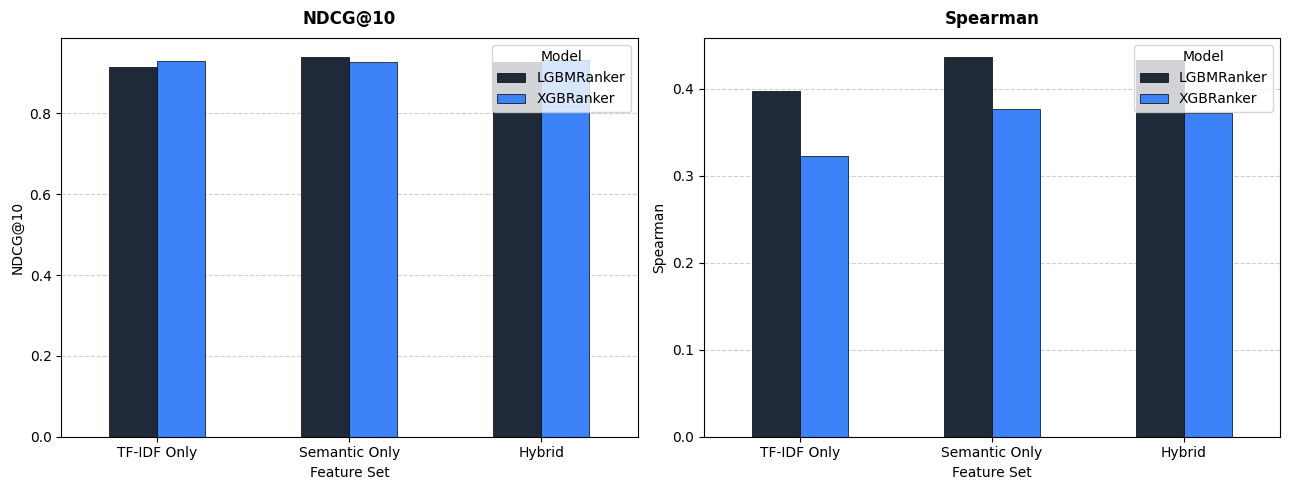

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# A sharp, professional color palette (Deep Navy and Crisp Blue)
custom_colors = ['#1F2937', '#3B82F6']

for ax, metric in zip(axes, ['NDCG@10', 'Spearman']):
    pivot = results_df.pivot(index='Feature Set', columns='Model', values=metric) \
                      .reindex(['TF-IDF Only', 'Semantic Only', 'Hybrid'])

    # Applied the new colors here
    pivot.plot(kind='bar', ax=ax, color=custom_colors, edgecolor='black', linewidth=0.5)

    ax.set_title(metric, fontweight='bold', pad=10)
    ax.set_xticklabels(pivot.index, rotation=0)
    ax.set_ylabel(metric)

    # Optional: Adds a subtle grid for a cleaner, more analytical look
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()